In [1]:
using CSV, DataFrames, CairoMakie

In [2]:
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=25,
                            xlabelsize=25
                            ),
                    Legend = (framevisible=false,),
                    size=(600, 500))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())
# update_theme!(theme_default())

In [3]:
datadir = joinpath(@__DIR__, "..", "data", "kummer2024", "data_models")
models = filter(x -> !startswith(x, "."), readdir(datadir))

56-element Vector{String}:
 "GW_advanced_high_density_Z0005.csv"
 "GW_advanced_high_density_Z0005_old.csv"
 "GW_advanced_high_density_Z005.csv"
 "GW_advanced_high_density_Z005_old.csv"
 "GW_advanced_low_density_Z0005.csv"
 "GW_advanced_low_density_Z0005_old.csv"
 "GW_advanced_low_density_Z005.csv"
 "GW_advanced_low_density_Z005_old.csv"
 "GW_no_drag_Advanced_nuclear_Z005.csv"
 "GW_no_drag_Advanced_thermal_Z005.csv"
 ⋮
 "no_drag_basic_thermal_Z005.csv"
 "simple_high_density_Z0005.csv"
 "simple_high_density_Z005.csv"
 "simple_low_density_Z0005.csv"
 "simple_low_density_Z005.csv"
 "simple_nuclear_low_density_Z0005.csv"
 "simple_nuclear_low_density_Z005.csv"
 "simple_thermal_high_density_Z0005.csv"
 "simple_thermal_high_density_Z005.csv"

In [4]:
modelname = "basic_high_density_Z0005.csv"#"simple_high_density_Z0005.csv"
filepath = joinpath(datadir, modelname)

"/home/cwbruenech/projects/BurstTimings/data/data_models/basic_high_density_Z0005.csv"

In [5]:
df = DataFrame(CSV.File(filepath))

Row,Column1,ID,time,a_in,a_out,e_in,e_out,m1,m2,m3,mc_3,st3,mdot_3,r3,lum3,m1_ppisn,m2_ppisn,incl,cbd,gw,merger,stability,time_sse
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64?,Float64?,Float64,Bool,Bool,Bool,String7,Float64
1,0,5,0.0,17.8487,1058.88,0.121269,0.190031,38.947,38.947,23.5751,8.80575,4,3.95847e21,1.68233e13,9.61813e38,37.5377,37.5377,1.49645,true,false,false,nuclear,8.88644
2,1,5,3.54678e5,13.5372,5363.07,0.478338,0.190031,46.3317,46.3317,8.80575,8.80575,4,1.4917e21,1.68233e13,9.61813e38,37.5377,37.5377,1.49645,true,false,false,nuclear,8.88644
3,2,6,0.0,17.7389,4102.5,0.109373,0.418902,37.9857,37.9857,30.6619,11.7617,4,7.47399e21,5.04244e13,1.61819e39,37.1132,37.1132,0.819596,true,false,false,nuclear,6.86445
4,3,6,2.3862e5,13.0841,17878.6,0.478508,0.418902,47.4358,47.4358,11.7617,11.7617,4,3.11033e21,5.04244e13,1.61819e39,37.1132,37.1132,0.819596,true,false,false,nuclear,6.86445
5,4,17,0.0,23.4828,19854.9,0.109442,0.970833,48.6057,48.6057,24.9506,9.14644,4,4.54788e21,1.08681e13,1.05791e39,36.8534,36.8534,0.689735,true,false,false,nuclear,8.31744
6,5,17,3.34623e5,18.1403,1.09316e5,0.478542,0.970833,56.5078,56.5078,9.14644,9.14644,4,1.84828e21,1.08681e13,1.05791e39,36.8534,36.8534,0.689735,true,false,false,nuclear,8.31744
7,6,24,0.0,18.2824,2587.31,0.125271,0.00106089,43.5738,43.5738,10.9101,3.90967,5,4.91811e20,3.9708e13,2.78712e38,39.4793,39.4793,1.48633,true,false,false,nuclear,24.1523
8,7,24,1.38026e6,14.4552,17263.0,0.473659,0.00106089,47.0741,47.0741,3.90967,3.90967,5,2.00835e20,3.9708e13,2.78712e38,39.4793,39.4793,1.48633,true,false,false,nuclear,24.1523
9,8,25,0.0,20.0675,3019.17,0.111134,0.414227,49.0958,49.0958,33.5955,20.3618,4,1.46944e22,3.58333e13,3.97858e39,36.3489,36.3489,1.77017,true,false,false,nuclear,4.649


In [7]:
IDs = unique(df.ID);

In [8]:
time = "end"

ErrorException: cannot assign a value to imported variable Base.time from module Main

## Outer, inner semi-major axis

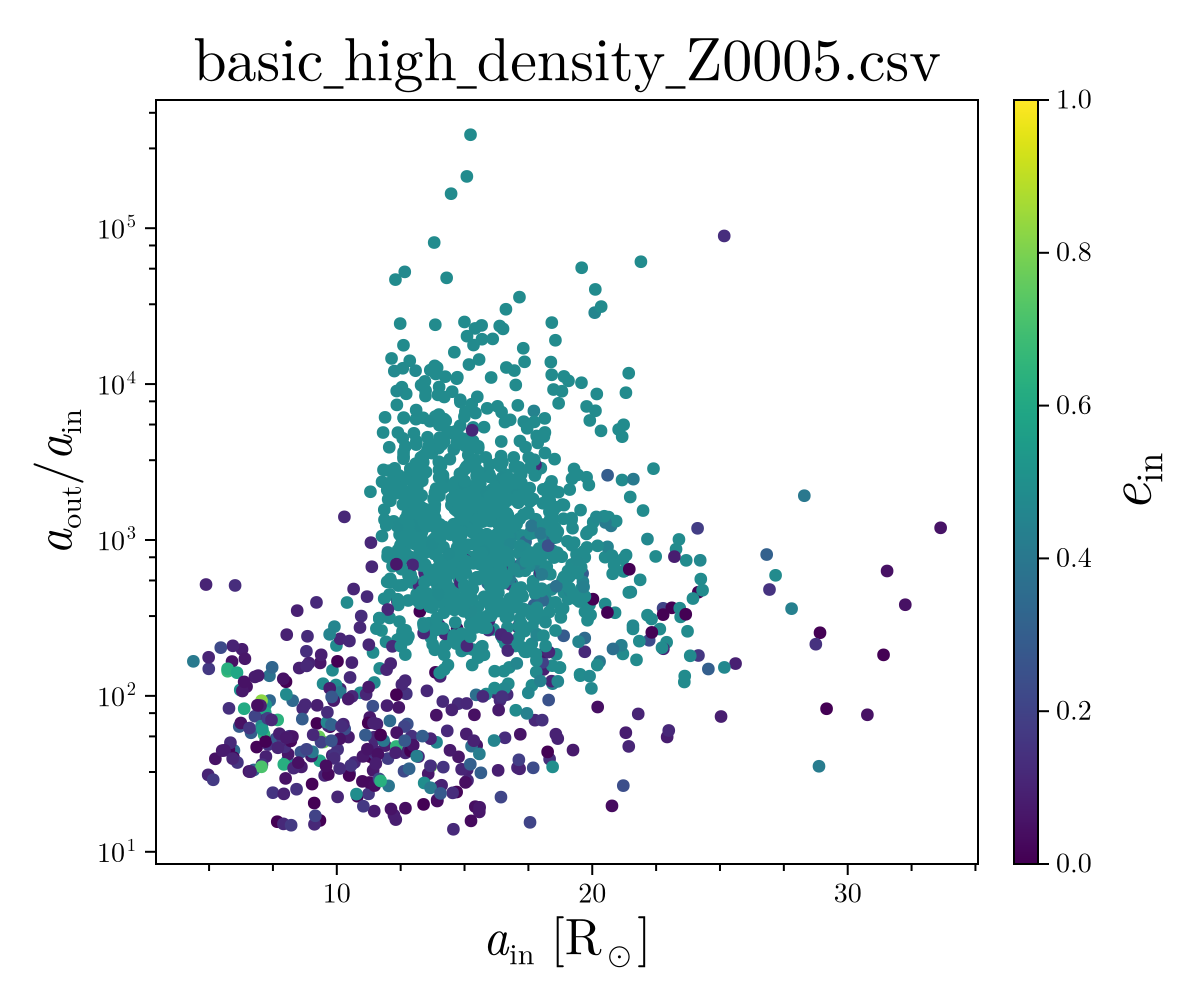

In [9]:
let df = df
    fig = Figure()
    ax = Axis(fig[1, 1], yscale=log10,title="$modelname", titlesize=30,
                         xlabel=L"$a_\text{in}$ [R_$\odot$]", ylabel=L"a_\text{out}/a_\text{in}")

    a_outs = Float64[]
    a_ins = Float64[]
    e_ins = Float64[]

    for id in IDs
        ids = findall(df.ID .== id) |> sort
        row = time == "onset" ? ids[1] : ids[2]
        push!(a_outs, df[row, :a_out])
        push!(a_ins, df[row, :a_in])
        push!(e_ins, df[row, :e_in])
    end

    # xlims!(0.4, 1.0)
    sc = scatter!(ax, a_ins, a_outs ./ a_ins, color=e_ins, colorrange=(0, 1))
    Colorbar(fig[1, 2], sc, label=L"e_\text{in}", labelsize=30, ticks=0.0:0.2:1.0)
    fig
end

## Outer mass ratio

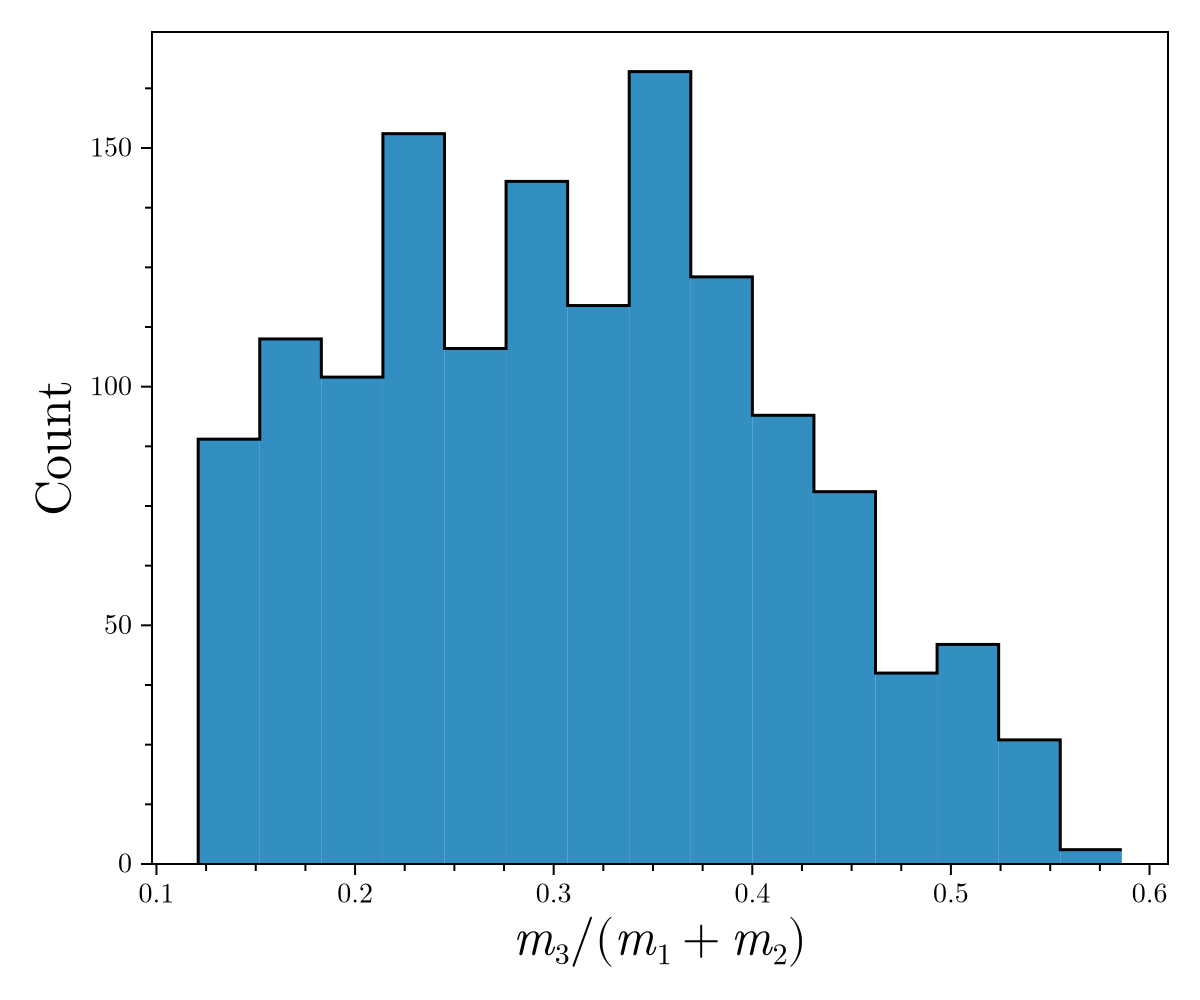

In [117]:
let df = df
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel="Count", xlabel=L"m_3/(m_1 + m_2)",
                         xticks=0.0:0.1:0.8)

    q_out = Float64[]

    for id in IDs
        ids = findall(df.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(q_out, df[row, :m3]/(df[row, :m1] + df[row, :m2]))

    end

    ylims!(0.0, nothing)
    hist!(ax, q_out)
    stephist!(ax, q_out, color=:black)
    fig
end

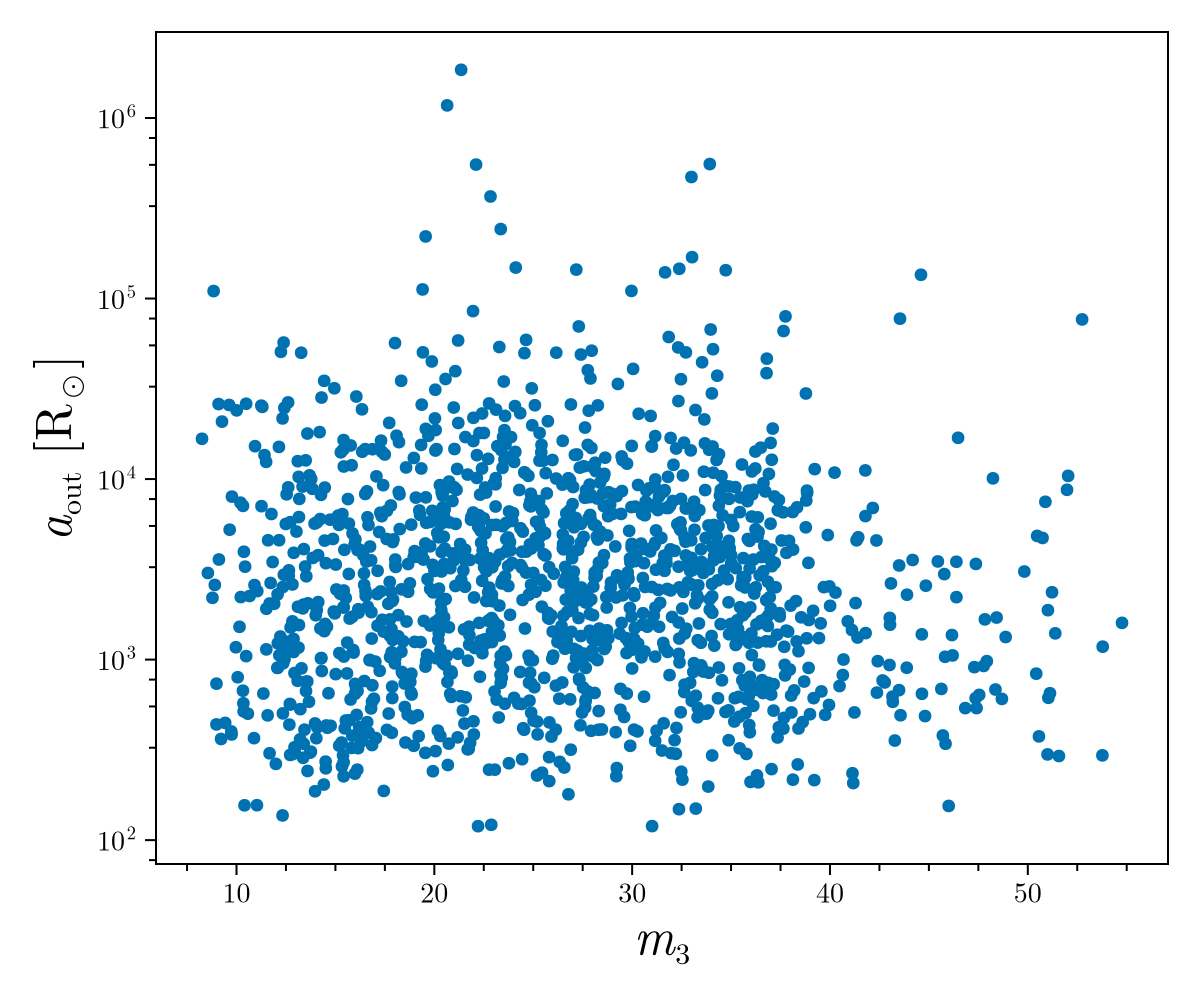

In [118]:
let df = df
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"$a_\text{out}$ [R_$\odot$]", xlabel=L"m_3", yscale=log10)

    m3 = Float64[]
    a_out = Float64[]

    for id in IDs
        ids = findall(df.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(m3, df[row, :m3])
        push!(a_out, df[row, :a_out])
    end

    scatter!(ax, m3, a_out)
    fig
end

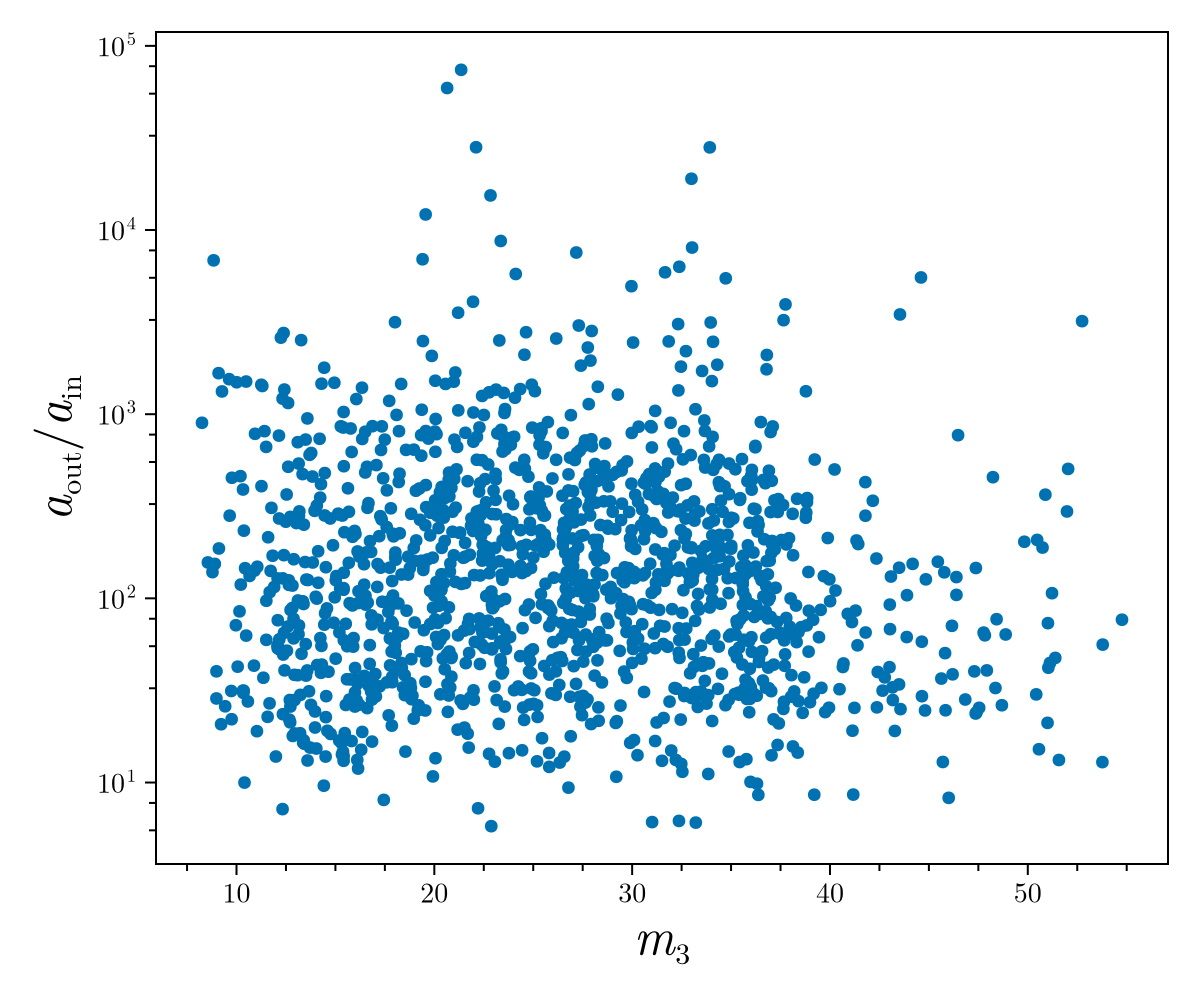

In [119]:
let df = df
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a_\text{out}/a_\text{in}", xlabel=L"m_3", yscale=log10)

    m3 = Float64[]
    α = Float64[]

    for id in IDs
        ids = findall(df.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(m3, df[row, :m3])
        push!(α, df[row, :a_out]/df[row, :a_in])
    end

    scatter!(ax, m3, α)
    fig
end

## Compare models

In [10]:
modelname1 = "advanced_high_density_Z0005.csv"
filepath1 = joinpath(datadir, modelname1)

modelname2 = "basic_low_density_Z0005.csv"
filepath2 = joinpath(datadir, modelname2)

cs = Makie.wong_colors()

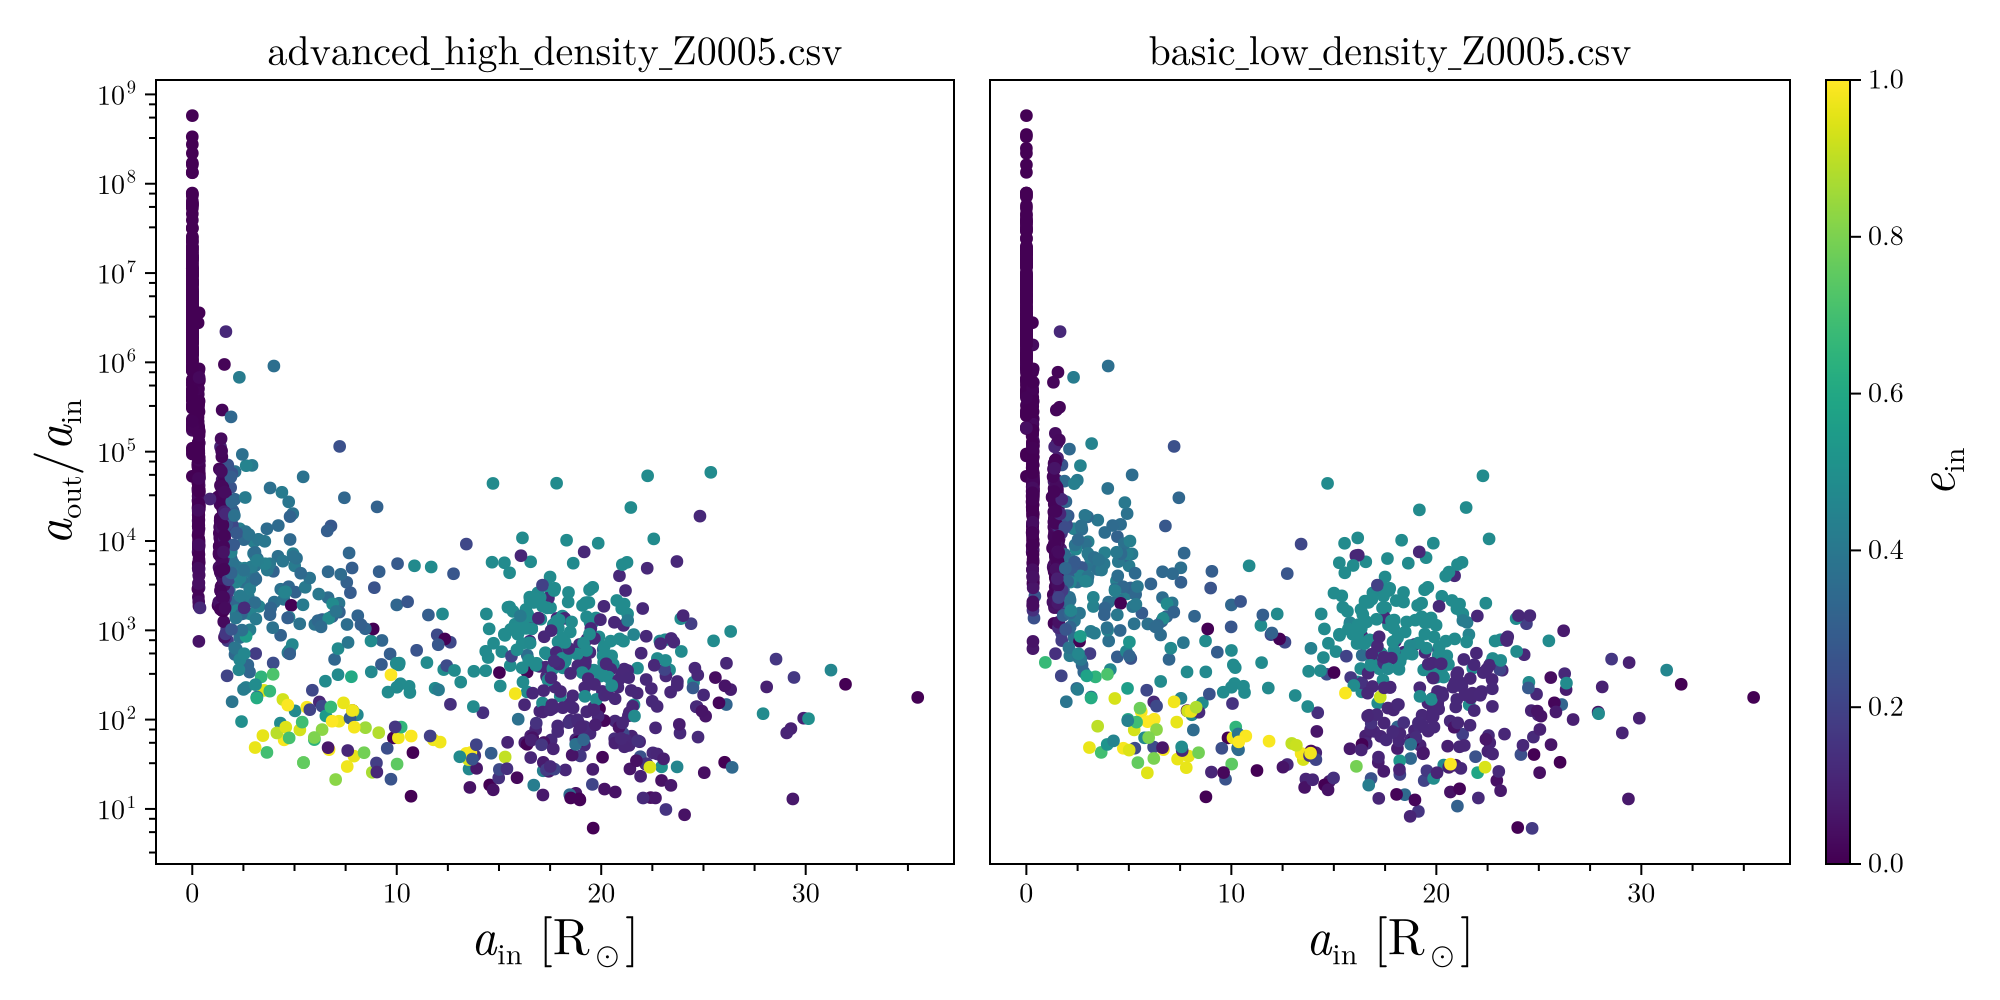

In [193]:
let
    df1 = DataFrame(CSV.File(filepath1))
    df2 = DataFrame(CSV.File(filepath2))

    fig = Figure(size=(1000, 500))
    ax1 = Axis(fig[1, 1],title="$modelname1", titlesize=20, yscale=log10, yticks=LogTicks(LinearTicks(9)),
                             xlabel=L"$a_\text{in}$ [R_$\odot$]", ylabel=L"a_\text{out}/a_\text{in}")
    ax2 = Axis(fig[1, 2],title="$modelname2", titlesize=20, yscale=log10, 
                             xlabel=L"$a_\text{in}$ [R_$\odot$]")

    hideydecorations!(ax2)

    linkyaxes!(ax1, ax2)
    linkxaxes!(ax1, ax2)

    a_outs1 = Float64[]
    a_ins1 = Float64[]
    e_ins1 = Float64[]

    a_outs2 = Float64[]
    a_ins2 = Float64[]
    e_ins2 = Float64[]

    for id in unique(df1.ID)
        ids = findall(df1.ID .== id) |> sort
        row = time == "onset" ? ids[1] : ids[2]

        a_out = df[row, :a_out]
        a_in = df[row, :a_in]
        e_in = df[row, :e_in]

        (a_out < 0.0 || a_in < 0.0 || e_in < 0.0) && continue

        push!(a_outs1, a_out)
        push!(a_ins1, a_in)
        push!(e_ins1, e_in)
    end

    for id in unique(df2.ID)
        ids = findall(df2.ID .== id) |> sort
        row = time == "onset" ? ids[1] : ids[2]

        a_out = df[row, :a_out]
        a_in = df[row, :a_in]
        e_in = df[row, :e_in]

        (a_out < 0.0 || a_in < 0.0 || e_in < 0.0) && continue

        push!(a_outs2, a_out)
        push!(a_ins2, a_in)
        push!(e_ins2, e_in)
    end

    # xlims!(0.4, 1.0)
    sc1 = scatter!(ax1, a_ins1, a_outs1 ./ a_ins1, color=e_ins1, colorrange=(0, 1))
    sc2 = scatter!(ax2, a_ins2, a_outs2 ./ a_ins2, color=e_ins2, colorrange=(0, 1))

    # Colorbar(fig[1, 2], sc, label=L"e_\text{in}", labelsize=30, ticks=0.0:0.2:1.0)
    Colorbar(fig[1, 3], colorrange=(0, 1), label=L"e_\text{in}", labelsize=25, ticks=0.0:0.2:1.0)
    fig
end

## Inclination

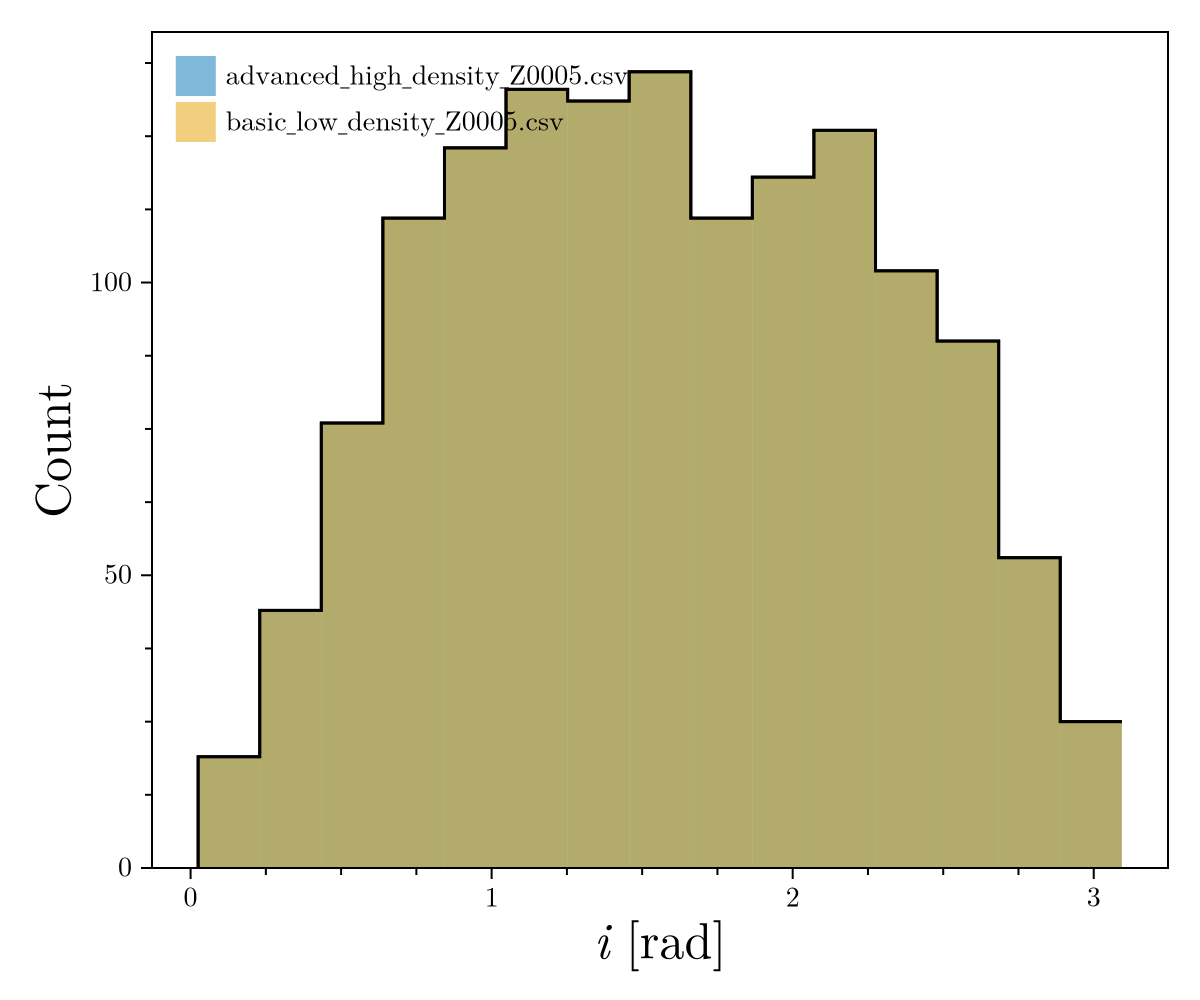

In [198]:
let 
    df1 = DataFrame(CSV.File(filepath1))
    df2 = DataFrame(CSV.File(filepath2))

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel="Count", xlabel=L"$i$ [rad]")

    incl1 = Float64[]
    incl2 = Float64[]

    for id in unique(df1.ID)
        ids = findall(df1.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(incl1, df1[row, :incl])
    end

    for id in unique(df2.ID)
        ids = findall(df2.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(incl2, df2[row, :incl])
    end

    ylims!(ax, 0.0, nothing)

    hist!(ax, incl1, color=(cs[1], 0.5), label=modelname1)
    stephist!(ax, incl1, color=:black)

    hist!(ax, incl2, color=(cs[2], 0.5), label=modelname2)
    stephist!(ax, incl2, color=:black)

    axislegend(ax, position=:lt)
    fig
end

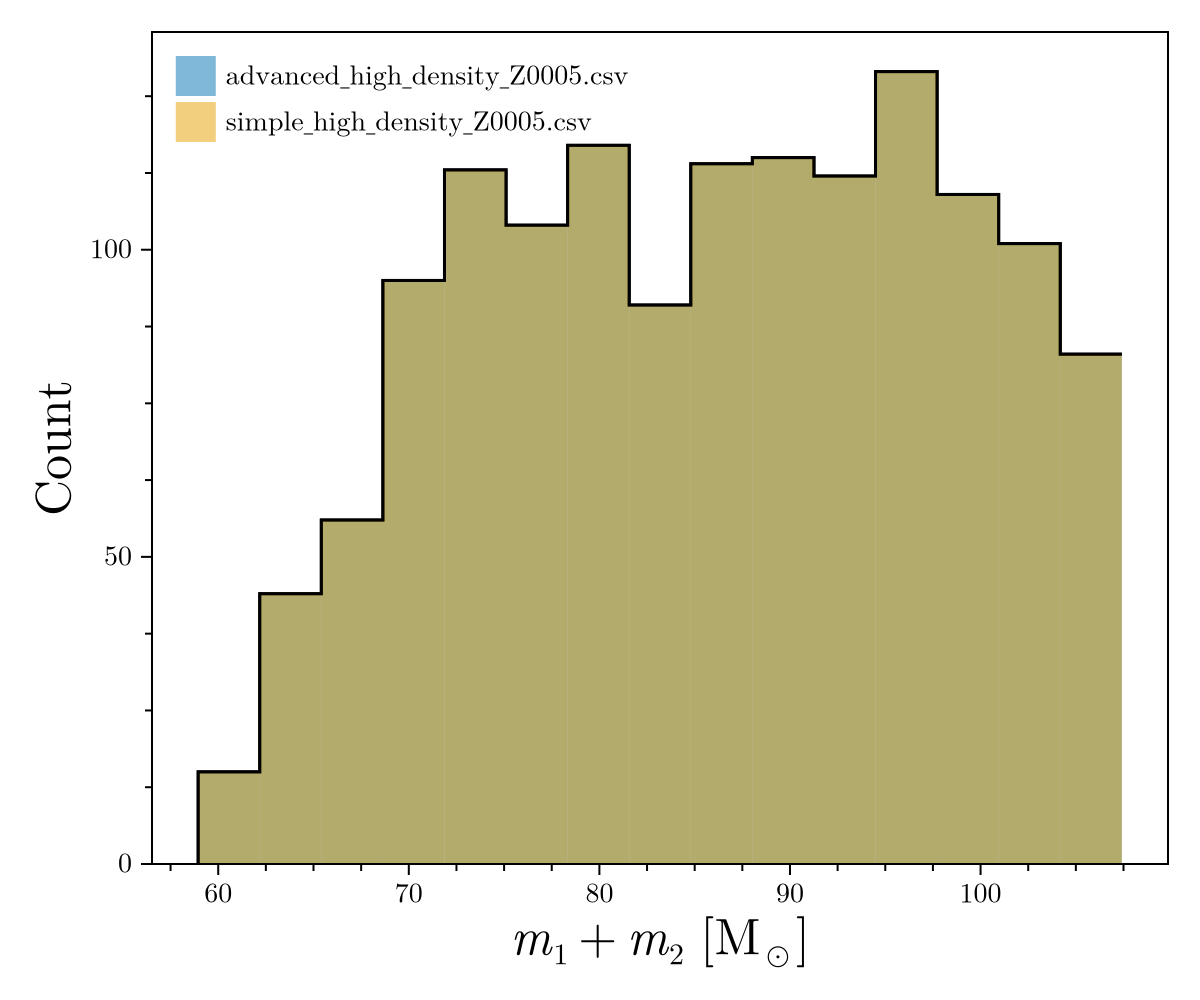

In [190]:
let 
    df1 = DataFrame(CSV.File(filepath1))
    df2 = DataFrame(CSV.File(filepath2))

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel="Count", xlabel=L"$m_1 + m_2$ [M$_\odot$]")

    M_in1 = Float64[]
    M_in2 = Float64[]

    for id in unique(df1.ID)
        ids = findall(df1.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(M_in1, df1[row, :m1] + df1[row, :m2])
    end

    for id in unique(df2.ID)
        ids = findall(df2.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(M_in2, df2[row, :m1] + df2[row, :m2])
    end

    ylims!(ax, 0.0, nothing)

    hist!(ax, M_in1, color=(cs[1], 0.5), label=modelname1)
    stephist!(ax, M_in1, color=:black)

    hist!(ax, M_in2, color=(cs[2], 0.5), label=modelname2)
    stephist!(ax, M_in2, color=:black)

    axislegend(ax, position=:lt)
    fig
end

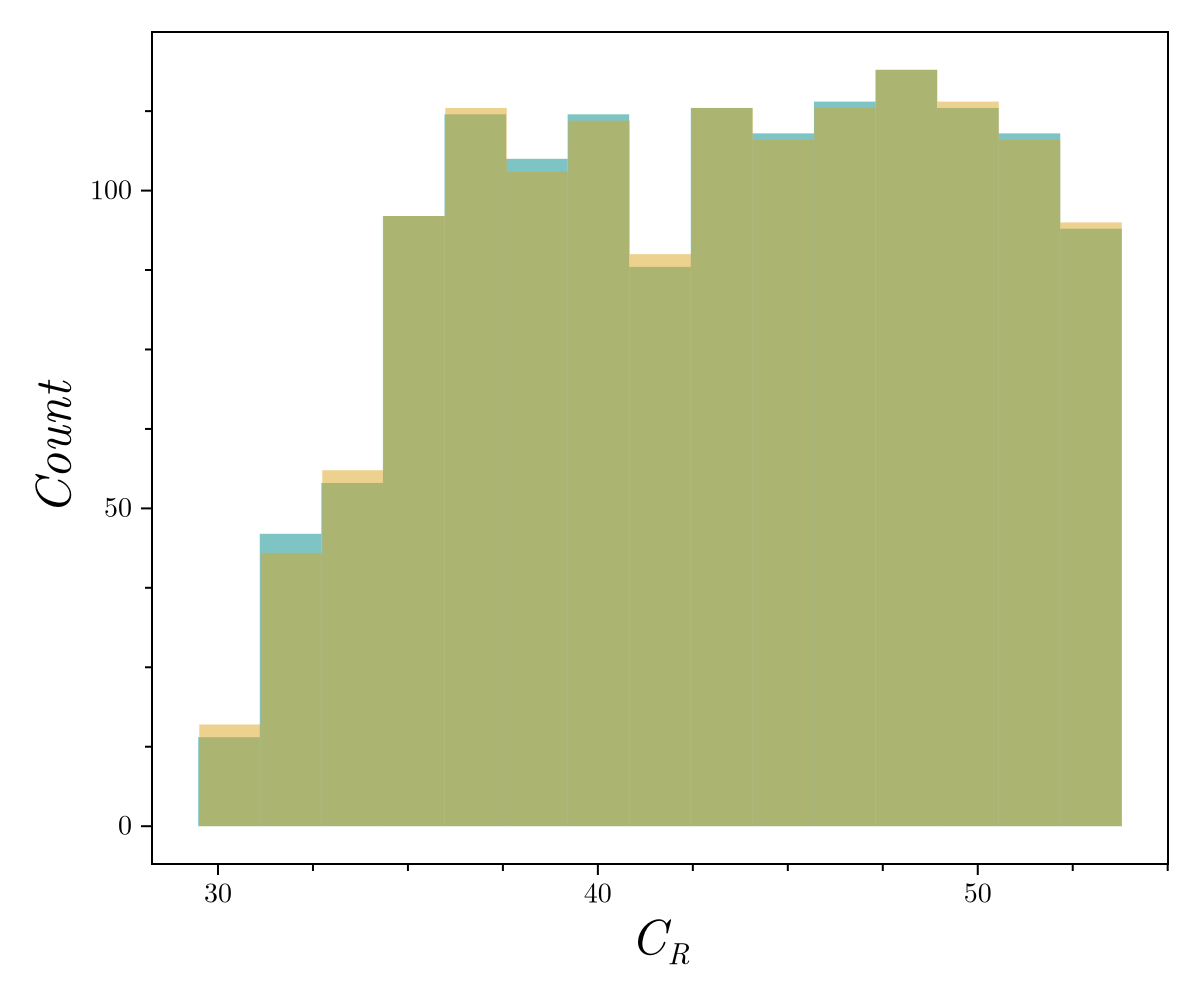

In [180]:
let 
    df1 = DataFrame(CSV.File(filepath1))
    df2 = DataFrame(CSV.File(filepath2))

    fig = Figure()
    ax = Axis(fig[1, 1], xlabel=L"C_R", ylabel=L"Count")

    C_R_1 = Float64[]
    C_R_2 = Float64[]

    for id in unique(df1.ID)
        ids = findall(df1.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(C_R_1, df1[row, :m1] + (df1[row, :m2]) / df1[row, :a_out])
    end

    for id in unique(df2.ID)
        ids = findall(df2.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(C_R_2, df2[row, :m1] + (df2[row, :m2]) / df2[row, :a_out])
    end

    hist!(ax, C_R_1, color=(:darkcyan, 0.5))
    hist!(ax, C_R_2, color=(:goldenrod, 0.5))
    fig
end

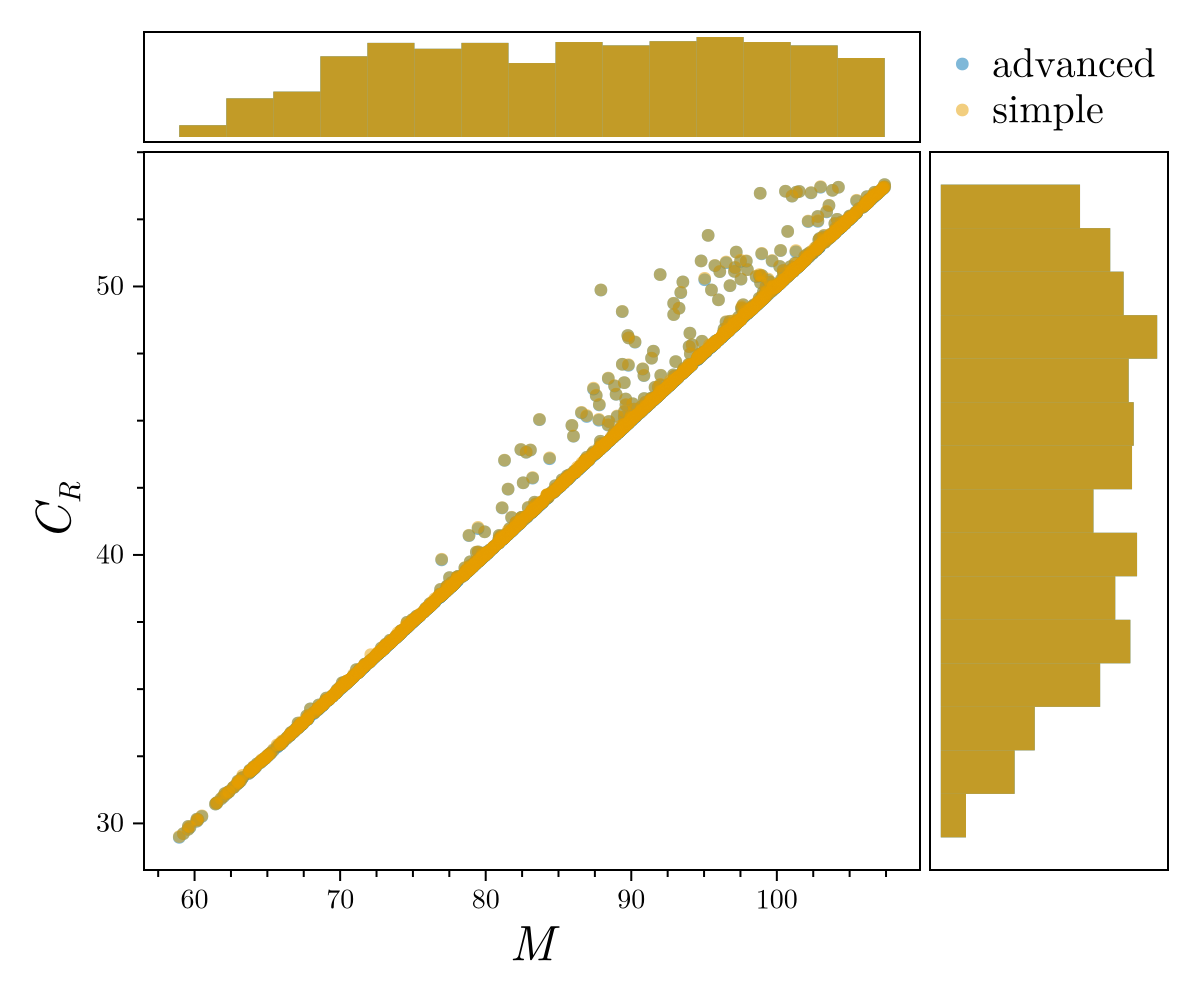

In [191]:
let 
    df1 = DataFrame(CSV.File(filepath1))
    df2 = DataFrame(CSV.File(filepath2))

    fig = Figure()
    ax = Axis(fig[2, 1], xlabel=L"M", ylabel=L"C_R")

    ax_C_hist = Axis(fig[1, 1])
    ax_M_hist = Axis(fig[2, 2])

    hidedecorations!(ax_M_hist)
    hidedecorations!(ax_C_hist)

    C_R_1 = Float64[]
    C_R_2 = Float64[]

    M_in1 = Float64[]
    M_in2 = Float64[]


    for id in unique(df1.ID)
        ids = findall(df1.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(C_R_1, df1[row, :m1] + (df1[row, :m2]) / df1[row, :a_out])
        push!(M_in1, df1[row, :m1] + df1[row, :m2])
    end

    for id in unique(df2.ID)
        ids = findall(df2.ID .== id)
        row = time == "onset" ? ids[1] : ids[2]
        push!(C_R_2, df2[row, :m1] + (df2[row, :m2]) / df2[row, :a_out])
        push!(M_in2, df2[row, :m1] + df2[row, :m2])
    end

    scatter!(ax, M_in1, C_R_1, color=(cs[1], 0.5), label=split(modelname1, "_")[1])
    scatter!(ax, M_in2, C_R_2, color=(cs[2], 0.5), label=split(modelname2, "_")[1])

    leg = Legend(fig[1, 2], ax, labelsize=20)
    leg.tellheight = true
    colgap!(fig.layout, 5.0)
    rowgap!(fig.layout, 5.0)

    hist!(ax_M_hist, M_in1, direction=:x)
    hist!(ax_C_hist, C_R_1)

    hist!(ax_M_hist, M_in2, direction=:x)
    hist!(ax_C_hist, C_R_1)

    fig
end

## Find most extreme systems

In [21]:
using StaticArrays

In [22]:
function get_most_extreme_systems(modelname; n=10)
    filepath = joinpath(datadir, modelname)
    df = DataFrame(CSV.File(filepath))

    m3_max = maximum(df.m3)
    aout_max = log10.(maximum(df.a_out))
    ein_max = maximum(df.e_in)

    m3s_a_outs_e_ins = Float64[]
    IDs = Int[]
    for id in unique(df.ID)
        ids = findall(df.ID .== id)
        # row = time == "onset" ? ids[1] : ids[2]
        row = ids[2]
        # push!(m3s, df[row, :m3])
        # push!(a_outs, df[row, :a_out])

        push!(m3s_a_outs_e_ins, df[row, :e_in] + df[row, :m3]/m3_max + (1 ./ (log10(df[row, :a_out])/aout_max)))
        push!(IDs, id)
    end

    sorted_indices = partialsortperm(m3s_a_outs_e_ins, 1:n, rev=true)
    # partialsort!(m3s_a_outs_e_ins, n, rev=true)#[end:-1:end-n]
    return SVector{n}(m3s_a_outs_e_ins[sorted_indices]), SVector{n}(IDs[sorted_indices])
end

get_most_extreme_systems (generic function with 1 method)

In [18]:
function get_average_systems(modelname; n=10)
    filepath = joinpath(datadir, modelname)
    df = DataFrame(CSV.File(filepath))

    m3_mean = sum(df.m3) / size(df, 1)
    logaout_mean = sum(log10.(df.a_out))/size(df, 1)
    ein_mean = sum(df.e_in)/size(df, 1)

    subdf = df[[findall(df.ID .== id)[2] for id in unique(df.ID)], :]

    closest_to_mean = partialsortperm(abs.((subdf.m3 .+ log10.(subdf.a_out) .+ subdf.e_in) .- (m3_mean + logaout_mean + ein_mean)), 1:n)
    return df.ID[closest_to_mean]
end

get_average_systems (generic function with 1 method)

In [25]:
avg_sys = let modelname = "basic_high_density_Z0005.csv"
    n = 5

    get_average_systems(modelname, n=n)
end

5-element Vector{Int64}:
 3824
 2651
 5945
 2869
 5843

In [26]:
extr_sys = let modelname = "basic_high_density_Z0005.csv"
    n = 5

    most_extreme_systems, most_extreme_system_IDs = get_most_extreme_systems(modelname, n=n)
    
    # most_extreme_systems, most_extreme_system_IDs
    most_extreme_system_IDs
end

5-element SVector{5, Int64} with indices SOneTo(5):
 10830
  1531
  4445
  1891
  7329

2651 [11.7060363953]
2869 [15.1911509262]
3824 [11.7907425033]
5843 [23.3441489461]
5945 [6.96048794219]


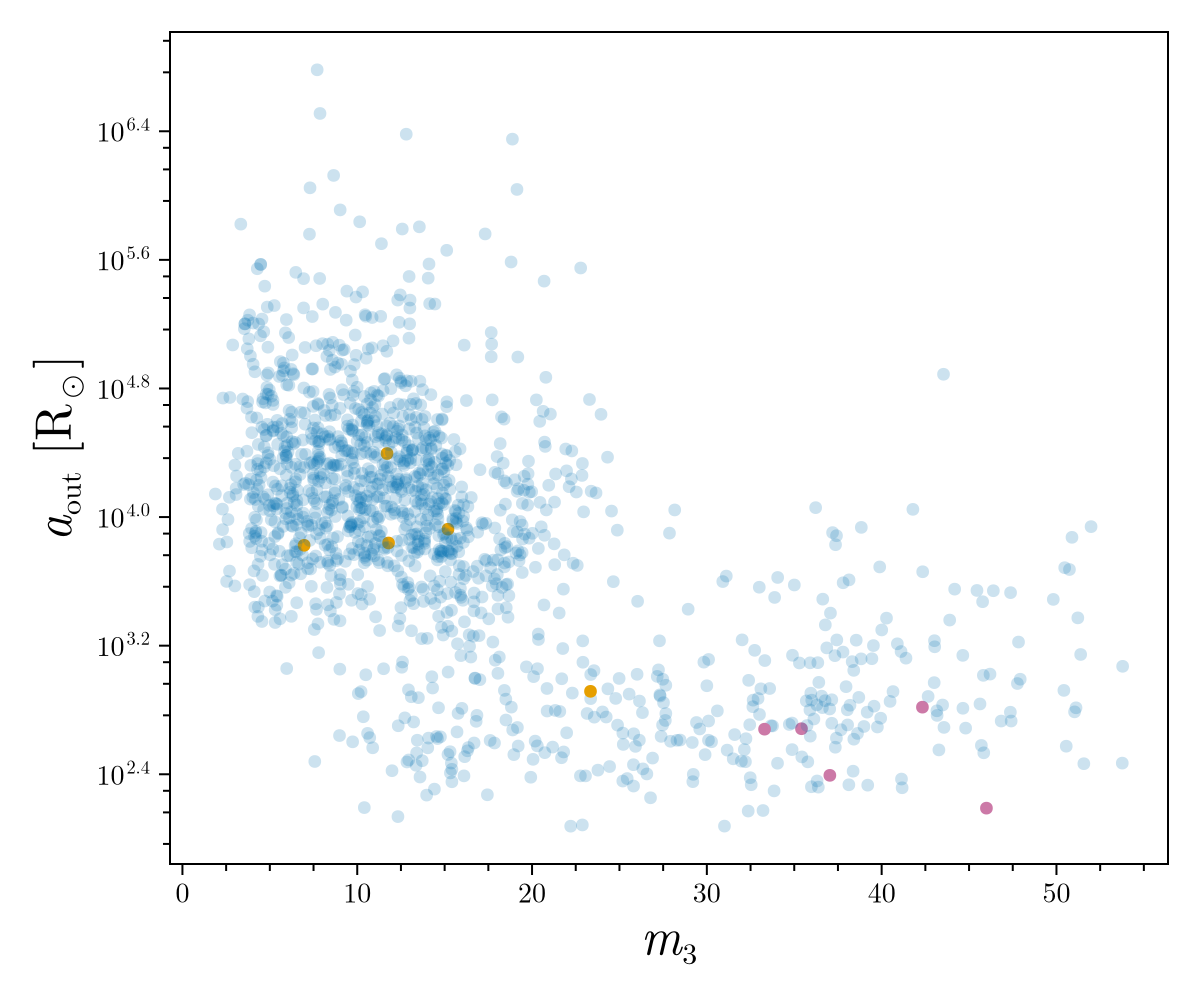

In [42]:
let df = df[[findall(df.ID .== id)[2] for id in unique(df.ID)], :]
    fig = Figure()
    ax = Axis(fig[1, 1], yscale=log10, yticks=LogTicks(LinearTicks(7)), 
                        xlabel=L"m_3", ylabel=L"$a_\text{out}$ [R$_\odot$]",
                        xticks=LinearTicks(7))

    for id in unique(df.ID)#[9074, 2330, 10153, 13275, 1662]
        subdf = df[df.ID .== id, :]
        if id in avg_sys#[1662, 2330, 2038]#[9074, 2330, 10153, 13275, 1662]
            println(id, " ", subdf.m3, )
            c = cs[2]
        elseif id in extr_sys#[3921, 4324, 6195]
            # println(id, " ", subdf.m3, " ", subdf.e_in)
            c = cs[4]
        else
            c = (cs[1], 0.2)
        end

        scatter!(ax, subdf.m3, subdf.a_out, color=c)
        # scatter!(ax, subdf.m3, subdf.a_out, color=subdf.e_)
    end

    fig
end

1891, 4445, 7329  extreme

2651 , 2869 , 5945  average

In [317]:
# let #modelname = "advanced_high_density_Z0005.csv"
#     n = 5
#     most_extreme_systems = Dict{String, Vector{SVector{n}}}(m => SVector{n}[] for m in models)
#     most_extreme_system_IDs = Dict{String, Vector{Int}}(m => Int[] for m in models)
#     for model in models
#         vals, IDs = get_most_extreme_systems(modelname, n=n)
#         push!(most_extreme_systems[model], vals)
#         append!(most_extreme_system_IDs[model], IDs)
#     end

#     most_extreme_system_IDs
#     most_extreme_systems
# end

In [5]:
let modelname = "basic_high_density_Z0005.csv"
    n = 5

    extremes = [1891, 4445, 7329]
    avgs = [2651, 2869, 5945]

    filepath = joinpath(datadir, modelname)
    df = DataFrame(CSV.File(filepath))
    
    # df_ex = df[map(x -> x in extremes, df.ID), :]
    # df_avg = df[map(x -> x in avgs, df.ID), :]

    df_ex = DataFrame()
    df_avg = DataFrame()

    for i in extremes
        subdf = df[df.ID .== i, :]
        row = subdf[2, :]
        push!(df_ex, row)
    end

    for i in avgs
        subdf = df[df.ID .== i, :]
        row = subdf[2, :]
        push!(df_avg, row)
    end

    df_ex
    df_avg


    df_ex = df_ex[!, [:a_in, :a_out, :e_in, :e_out, :m1, :m2, :m3, :incl]]
    df_avg = df_avg[!, [:a_in, :a_out, :e_in, :e_out, :m1, :m2, :m3, :incl]]

    CSV.write(joinpath(@__DIR__, "..", "data", "extreme_examples.csv"), df_ex)
    CSV.write(joinpath(@__DIR__, "..", "data", "average_examples.csv"), df_avg)
end

"/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/average_examples.csv"